# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





###[LINK TO GITHUB REPOSITORY](https://github.com/L-nsamba/principle_component_analysis_group_8)

Library importations and loading of the csv data

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Loading data from the csv file
numeric_data = np.genfromtxt(
    "/content/sample_data/African_countries_development_indicators_2000-2023_WorldBankGroup.csv",
    delimiter=",",
    dtype=float,
    usecols=range(2, 12), # This range extracts only numeric fields, ignoring the country name(0), country code(1) and year(13)
    skip_header=1,
    filling_values=np.nan,
)


Verifying the row number, column number and shape of the matrix

In [86]:
row_count = numeric_data.shape[0]

print(f"Row number: {numeric_data.shape[0]}")
print(f"Column number: {numeric_data.shape[1]}")
print(numeric_data.shape)
print(numeric_data[1])

Row number: 1032
Column number: 10
(1032, 10)
[2.00000000e+01 1.36013867e-01 5.33586202e+02 6.29000000e+02
 3.95882654e+00 1.66680000e+01 1.03800000e+02 4.70320000e+01
 3.35370941e+00 5.17224790e+01]


Filtering out unique countries from the dataset, which we shall use while creating country-specific imputation

In [87]:
countries = np.genfromtxt(
    "/content/sample_data/African_countries_development_indicators_2000-2023_WorldBankGroup.csv",
    delimiter=",",
    dtype=str,
    usecols=0,
    skip_header=1,
)

unique_countries = np.unique(countries)
print(unique_countries)

['AGO' 'BDI' 'BEN' 'BFA' 'BWA' 'CAF' 'CIV' 'CMR' 'COM' 'CPV' 'ERI' 'ETH'
 'GAB' 'GHA' 'GIN' 'GNB' 'GNQ' 'KEN' 'LBR' 'LSO' 'MDG' 'MLI' 'MOZ' 'MRT'
 'MUS' 'MWI' 'NAM' 'NER' 'NGA' 'RWA' 'SDN' 'SEN' 'SLE' 'SSD' 'STP' 'SWZ'
 'TCD' 'TGO' 'TZA' 'UGA' 'ZAF' 'ZMB' 'ZWE']


Cleaning the data (handling of the NaN values) and carrying out country-specific imputation to replace the NaN values with the country-specific mean

In [88]:
clean_matrix = numeric_data.copy()

for country in unique_countries:

  # Finding all rows belonging to this country in the dataset
  country_mask = countries == country

  # Fitering through each numerical variable
  for col_idx in range(clean_matrix.shape[1]):

    # Getting the country-specific values and variables
    country_values = clean_matrix[country_mask, col_idx]

    # Calculation of the country-specific mean
    country_mean = np.nanmean(country_values)

    # Finding missing values in different columns for country
    missing_mask = country_mask & np.isnan(clean_matrix[:, col_idx])

    # Replacing the missing values with the countries mean
    clean_matrix[missing_mask, col_idx] = country_mean


Verifying that they are no more NaN values in the data after the imputation

In [89]:
print("Remaining NaNs:", np.isnan(clean_matrix).sum())
len(clean_matrix)

Remaining NaNs: 0


1032

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

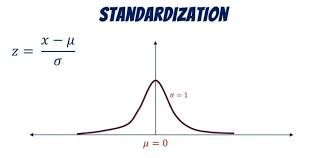


Calculating the matrix mean and standard deviation

In [90]:
matrix_mean = np.mean(clean_matrix, axis = 0)
matrix_std = np.std(clean_matrix, axis = 0)

print(matrix_mean)
print(matrix_std)

[  38.78419403   13.12862471 1890.7275018   478.27034884    5.34551765
    7.91423681   57.23284884   58.73141414    2.42955373   38.55317733]
[2.57227490e+01 1.68356865e+01 2.43965091e+03 3.12058425e+02
 2.36424017e+00 6.90609792e+00 2.39660022e+01 6.86948661e+00
 1.06348050e+00 1.65508031e+01]


Standardization of the data

In [91]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
standardized_data = (clean_matrix - matrix_mean) / matrix_std
standardized_data[:5]  # Display the first few rows of standardized data

array([[-0.56697649, -0.77356983, -0.5439277 ,  0.57915325, -1.54817811,
         1.26435554,  2.13081643, -1.78039711,  0.83004224,  0.72225426],
       [-0.73025609, -0.77173038, -0.55628504,  0.48301741, -0.58652718,
         1.26754113,  1.94305044, -1.70309876,  0.86899166,  0.79568959],
       [-0.4853367 , -0.76374955, -0.36548739,  0.39649515, -1.0175343 ,
         1.23336844,  1.71773126, -1.58052774,  0.919549  ,  0.86638975],
       [-0.44257299, -0.75779165, -0.3103166 ,  0.19140535, -0.94690644,
         1.23525083,  1.47154919, -1.23930864,  1.00029013,  0.93356057],
       [-0.4036969 , -0.7522004 , -0.18004884,  0.06642875, -0.79715979,
         1.21613729,  1.1919865 , -1.10756663,  1.09536921,  0.99640789]])

Verifying the mean is 0 and the standard deviation is 1

In [92]:
print(standardized_data.mean())
print(standardized_data.std())

-2.2032332891786052e-17
1.0


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [93]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)
cov_matrix

array([[ 1.00096993,  0.68081184,  0.64657971, -0.58625212, -0.16751701,
         0.38348755, -0.62235101,  0.60239285, -0.33362985,  0.67636129],
       [ 0.68081184,  1.00096993,  0.5010149 , -0.42226549,  0.0899974 ,
         0.33702529, -0.52341022,  0.52735954, -0.30372307,  0.51102034],
       [ 0.64657971,  0.5010149 ,  1.00096993, -0.38731705, -0.08590134,
         0.48249623, -0.32956333,  0.32671786, -0.15758554,  0.55281834],
       [-0.58625212, -0.42226549, -0.38731705,  1.00096993,  0.09657979,
        -0.28968564,  0.75056682, -0.69960682,  0.12939833, -0.31561918],
       [-0.16751701,  0.0899974 , -0.08590134,  0.09657979,  1.00096993,
         0.30056401,  0.0230284 , -0.12437628, -0.25693125, -0.19063989],
       [ 0.38348755,  0.33702529,  0.48249623, -0.28968564,  0.30056401,
         1.00096993, -0.22736953,  0.04849902, -0.35042324,  0.380293  ],
       [-0.62235101, -0.52341022, -0.32956333,  0.75056682,  0.0230284 ,
        -0.22736953,  1.00096993, -0.86491509

**Explain why we need to compute a covariance matrix, provide atleast 2 reasons**

*   Covariance shows relationship between variables for example in our data the covariance of the first column of data is compared against every individual column including itself, and the values would be what becomes the first row of the new 10 by 10 matrix
*   The covariance matrix is what we use to get the eigenvectors and eigenvalues. That is to say, the new 10 by 10 matrix we have as the covariance matrix will give us both 10 eigenvectors and 10 eigenvalues



### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [94]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # Perform eigendecomposition
eigenvalues, eigenvectors

(array([0.1055129 , 0.1771331 , 0.24555439, 0.31944726, 0.43307032,
        0.61435824, 0.74231742, 1.21261512, 1.6310248 , 4.52866578]),
 array([[ 0.02136206, -0.85113188,  0.16437014,  0.06107895, -0.0306936 ,
         -0.02610557,  0.19684199,  0.16350424,  0.00177672, -0.42102595],
        [ 0.06242211,  0.19917108,  0.0367504 , -0.62589723, -0.21154789,
         -0.59478099,  0.14108082, -0.01311587,  0.11622265, -0.36226505],
        [ 0.07557555,  0.22047003, -0.08039974,  0.39803787, -0.66303712,
          0.05747108, -0.2338797 ,  0.39319621,  0.14760926, -0.32675744],
        [ 0.05309912, -0.18570208, -0.68573501,  0.16862502,  0.04650002,
         -0.42747378,  0.20277287,  0.26345332,  0.20472094,  0.35594533],
        [-0.0077726 , -0.1093458 ,  0.23904176,  0.35132351,  0.03838923,
         -0.39383794, -0.35048149, -0.50212857,  0.52437234,  0.02991873],
        [-0.15350685, -0.08112839, -0.36320514, -0.37824258,  0.23223321,
          0.39311924, -0.40310736,  0.09343

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [95]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]  # Sort eigenvalues accordingly
sorted_eigenvectors = eigenvectors[:, sorted_indices] # Sorting eigenvectors accordingly
sorted_eigenvectors

array([[-0.42102595,  0.00177672,  0.16350424,  0.19684199, -0.02610557,
        -0.0306936 ,  0.06107895,  0.16437014, -0.85113188,  0.02136206],
       [-0.36226505,  0.11622265, -0.01311587,  0.14108082, -0.59478099,
        -0.21154789, -0.62589723,  0.0367504 ,  0.19917108,  0.06242211],
       [-0.32675744,  0.14760926,  0.39319621, -0.2338797 ,  0.05747108,
        -0.66303712,  0.39803787, -0.08039974,  0.22047003,  0.07557555],
       [ 0.35594533,  0.20472094,  0.26345332,  0.20277287, -0.42747378,
         0.04650002,  0.16862502, -0.68573501, -0.18570208,  0.05309912],
       [ 0.02991873,  0.52437234, -0.50212857, -0.35048149, -0.39383794,
         0.03838923,  0.35132351,  0.23904176, -0.1093458 , -0.0077726 ],
       [-0.23177859,  0.51131851,  0.09343405, -0.40310736,  0.39311924,
         0.23223321, -0.37824258, -0.36320514, -0.08112839, -0.15350685],
       [ 0.38002767,  0.21616912,  0.36859827,  0.04290905, -0.06430149,
        -0.15977299, -0.12693988,  0.37478334

Verifying the magnitude of the eigen vectors is equal to 1, which indicates that the vectors are normalized

In [96]:
norm = np.linalg.norm(sorted_eigenvectors[:, 0])
print("Vector Norm:", norm)

Vector Norm: 0.9999999999999999


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

Obtaining the explained variance ratio, which will help us understand the amount of information each component contains

In [97]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
print(explained_variance_ratio)

[0.45242775 0.16294443 0.12114401 0.07415981 0.06137629 0.04326507
 0.03191377 0.02453164 0.01769615 0.01054107]


Obtaining the cumulative variance and converting it to a percentage to help us conceptualize the total percentage each principle component takes of the total variance

In [98]:
cumulative_variance = np.cumsum(explained_variance_ratio)
cumulative_variance_percentage = cumulative_variance * 100

print(cumulative_variance_percentage)

[ 45.24277539  61.53721889  73.65161994  81.06760112  87.2052304
  91.53173716  94.72311432  97.1762788   98.94589341 100.        ]


From the cumulative variance percentage calculated above, we were able to note that the first six principal components retain 91.53% of the information. That is the logic we used for deciding the number of principal components to keep

In [99]:
# Step 6: Project Data onto Principal Components
num_components = 6  # Decide on the number of principal components to keep
selected_eigenvectors = sorted_eigenvectors[:, :num_components] # Selecting the eigenvalues for the 6 principal components
reduced_data = standardized_data @ selected_eigenvectors  # Project data onto the principal components
reduced_data[:5]

array([[ 1.90910922,  0.51290653,  2.59493446, -0.40621187,  0.9974431 ,
         0.95460831],
       [ 1.85822634,  0.91465834,  2.00489211, -0.83084732,  0.63854147,
         1.08076327],
       [ 1.50946791,  0.57094886,  2.23334541, -0.72828276,  0.80062265,
         1.00165241],
       [ 1.17474438,  0.36855557,  2.02620221, -0.87815246,  0.79432474,
         1.04488192],
       [ 0.91922118,  0.28370406,  1.88023602, -1.05571633,  0.74468416,
         1.04197717]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [100]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1032, 6)


array([[ 1.90910922,  0.51290653,  2.59493446, -0.40621187,  0.9974431 ,
         0.95460831],
       [ 1.85822634,  0.91465834,  2.00489211, -0.83084732,  0.63854147,
         1.08076327],
       [ 1.50946791,  0.57094886,  2.23334541, -0.72828276,  0.80062265,
         1.00165241],
       [ 1.17474438,  0.36855557,  2.02620221, -0.87815246,  0.79432474,
         1.04488192],
       [ 0.91922118,  0.28370406,  1.88023602, -1.05571633,  0.74468416,
         1.04197717]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

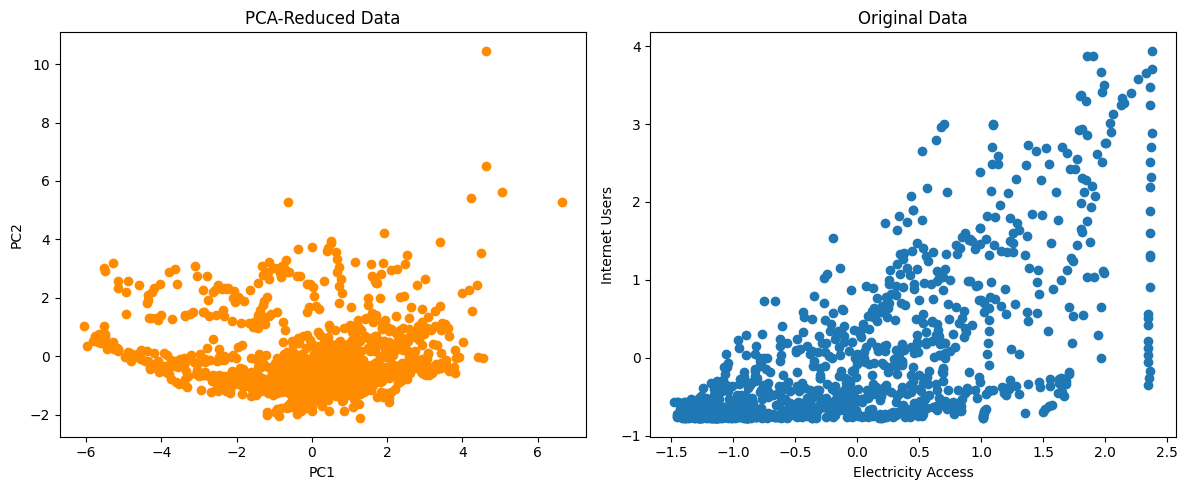

In [101]:
# Step 8: Visualize Before and After PCA
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data (first two features for simplicity)
axes[1].scatter(standardized_data[:, 0], standardized_data[:, 1])
axes[1].set_xlabel("Electricity Access")
axes[1].set_ylabel("Internet Users")
axes[1].set_title("Original Data")

# Plot reduced data after PCA
axes[0].scatter(reduced_data[:, 0], reduced_data[:, 1], color="darkorange")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA-Reduced Data")

plt.tight_layout()
plt.show()

Verifying that both graphs have the same number of plots

In [102]:
count_original = standardized_data.shape[0]
count_reduced = reduced_data.shape[0]

print("Number of plots in original graph:", count_original)
print("Number of plots in reduced graph:", count_reduced)

Number of plots in original graph: 1032
Number of plots in reduced graph: 1032


##Please make sure you do not use more than 5 lines to answer each of the following points:

###1. Interpret the Visual you just created of the before and after PCA


*   The original data indicates a positive correlation between electricity access and internet users
*   After the PCA, the graph captures the direction of variation of the dataset. For context, our PC1 and PC2 retain 61.54% of the total covariance hence the PCA plot shows the same observation as the initial plot using two principle directions that capture the greatest variation across all the 10 features



###2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

*   We kept six components because they retained 91.53% of the information, and reduced the dimensionality of the data. The tradeoff was that we neglected the remaining 8.47% of the information




###3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


*   We lost 4 out of the 6 features including infant_mortality, life_expectancy, pop_growth, and urban_pop_pct
